# Anomalias e extremos

**Objetivo:** identificar dias excepcionalmente altos ou baixos, medir a frequencia desses eventos e inspecionar o contexto temporal em torno deles.

Nesta etapa vamos combinar duas visoes:
- **extremos brutos**, baseados no proprio nivel observado da serie;
- **anomalias ajustadas**, baseadas no desvio em relacao ao valor esperado pela tendencia + sazonalidade, quando a decomposicao estiver disponivel.

Essa combinacao e util porque, em series de saude, um valor alto pode ser apenas sazonal para o inverno, enquanto outro pode ser realmente incomum mesmo depois de controlar tendencia e calendario.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [3]:

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
try:
    from statsmodels.tsa.seasonal import MSTL
    metodo_decomposicao = "MSTL"
except ImportError:
    from statsmodels.tsa.seasonal import STL
    metodo_decomposicao = "STL"

In [4]:
meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

dias_semana = {
    0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sab", 6: "Dom"
}

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [5]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.parquet"

df_internacoes = pd.read_parquet(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

## Anomalias e extremos

In [6]:
if not pd.api.types.is_datetime64_any_dtype(df_serie["data_dia"]):
    df_serie = df_serie.copy()
    df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"])

# Reorganizamos a serie diaria em frequencia regular para facilitar a deteccao de extremos.
serie_extremos = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_extremos = int(serie_extremos.isna().sum())
if faltantes_extremos > 0:
    print(f"Foram encontrados {faltantes_extremos} dias faltantes. A serie sera interpolada para a analise de extremos.")
    serie_extremos = serie_extremos.interpolate(method="time").ffill().bfill()

df_extremos = pd.DataFrame(index=serie_extremos.index)
df_extremos["num_internacoes"] = serie_extremos
df_extremos["ano"] = df_extremos.index.year
df_extremos["mes"] = df_extremos.index.month
df_extremos["mes_nome"] = pd.Categorical(
    df_extremos["mes"].map(meses),
    categories=list(meses.values()),
    ordered=True,
)
df_extremos["dia_semana_nome"] = pd.Categorical(
    pd.Index(df_extremos.index.dayofweek).map(dias_semana),
    categories=list(dias_semana.values()),
    ordered=True,
)

serie_decomp = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

# Caso haja lacunas na serie, interpolamos apenas para viabilizar a decomposicao.
faltantes_decomp = int(serie_decomp.isna().sum())
if faltantes_decomp > 0:
    print(f"Foram encontrados {faltantes_decomp} dias faltantes. A serie sera interpolada para a decomposicao.")
    serie_decomp = serie_decomp.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a decomposicao.")

print("Metodo selecionado:", metodo_decomposicao)
display(serie_decomp.head().to_frame(name="num_internacoes"))

if metodo_decomposicao == "MSTL":
    periodos_decomposicao = (7, 365)
    resultado_decomp = MSTL(
        serie_decomp,
        periods=periodos_decomposicao,
        stl_kwargs={"robust": True},
    ).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal["seasonal_7"]
    df_decomp["sazonal_365"] = resultado_decomp.seasonal["seasonal_365"]
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"] + df_decomp["sazonal_365"]
    df_decomp["residuo"] = resultado_decomp.resid
else:
    from statsmodels.tsa.seasonal import STL

    periodos_decomposicao = (7,)
    resultado_decomp = STL(serie_decomp, period=7, robust=True).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal
    df_decomp["sazonal_365"] = np.nan
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"]
    df_decomp["residuo"] = resultado_decomp.resid

# Adicionamos chaves de calendario para resumir e comparar os componentes depois.
df_decomp["ano"] = df_decomp.index.year
df_decomp["mes"] = df_decomp.index.month
df_decomp["mes_nome"] = pd.Categorical(
    df_decomp["mes"].map(meses),
    categories=list(meses.values()),
    ordered=True,
)
df_decomp["dia_semana_num"] = df_decomp.index.dayofweek
df_decomp["dia_semana_nome"] = pd.Categorical(
    df_decomp["dia_semana_num"].map(dias_semana),
    categories=list(dias_semana.values()),
    ordered=True,
)

# Sempre que a decomposicao estiver disponivel, usamos tendencia + sazonalidade como referencia.
usa_decomposicao = "df_decomp" in globals() and {"tendencia", "sazonal_total", "residuo"}.issubset(df_decomp.columns)

if usa_decomposicao:
    componentes_extremos = df_decomp[["tendencia", "sazonal_total", "residuo"]].copy()
    componentes_extremos.index = pd.to_datetime(componentes_extremos.index)
    df_extremos = df_extremos.join(componentes_extremos, how="left")
    df_extremos["valor_esperado"] = df_extremos["tendencia"] + df_extremos["sazonal_total"]
    df_extremos["desvio_ajustado"] = df_extremos["num_internacoes"] - df_extremos["valor_esperado"]
    metodo_referencia = "Tendencia + sazonalidade da decomposicao"
else:
    df_extremos["tendencia"] = (
        df_extremos["num_internacoes"]
        .rolling(window=30, center=True, min_periods=15)
        .median()
        .bfill()
        .ffill()
    )
    df_extremos["sazonal_total"] = 0.0
    df_extremos["residuo"] = df_extremos["num_internacoes"] - df_extremos["tendencia"]
    df_extremos["valor_esperado"] = df_extremos["tendencia"]
    df_extremos["desvio_ajustado"] = df_extremos["residuo"]
    metodo_referencia = "Mediana movel de 30 dias"

# Padronizamos o desvio ajustado com z-score robusto para reduzir a sensibilidade a outliers.
centro_desvio = df_extremos["desvio_ajustado"].median()
escala_robusta = median_abs_deviation(df_extremos["desvio_ajustado"].dropna(), scale="normal")
if np.isnan(escala_robusta) or escala_robusta == 0:
    escala_robusta = df_extremos["desvio_ajustado"].std()

df_extremos["z_robusto"] = (df_extremos["desvio_ajustado"] - centro_desvio) / escala_robusta

# Combinamos quantis extremos mais conservadores com limiares robustos no desvio ajustado.
q_superior = df_extremos["num_internacoes"].quantile(0.995)
q_inferior = df_extremos["num_internacoes"].quantile(0.005)
df_extremos["pico_extremo"] = (df_extremos["num_internacoes"] >= q_superior) | (df_extremos["z_robusto"] >= 5)
df_extremos["vale_extremo"] = (df_extremos["num_internacoes"] <= q_inferior) | (df_extremos["z_robusto"] <= -5)
df_extremos["extremo"] = df_extremos["pico_extremo"] | df_extremos["vale_extremo"]

print("Referencia usada para o valor esperado:", metodo_referencia)
print(f"Limiar bruto superior (q99.5): {q_superior:.1f}")
print(f"Limiar bruto inferior (q0.5): {q_inferior:.1f}")
print(f"Centro do desvio ajustado: {centro_desvio:.2f}")
print(f"Escala robusta (MAD normalizada): {escala_robusta:.2f}")

display(df_extremos.head().round(2))

Nenhum dia faltante foi encontrado para a decomposicao.
Metodo selecionado: MSTL


,num_internacoes
data_dia,
2008-01-01,79
2008-01-02,46
2008-01-03,53
2008-01-04,46
2008-01-05,42


Referencia usada para o valor esperado: Tendencia + sazonalidade da decomposicao
Limiar bruto superior (q99.5): 111.9
Limiar bruto inferior (q0.5): 9.1
Centro do desvio ajustado: -0.08
Escala robusta (MAD normalizada): 5.75


,num_internacoes,ano,mes,mes_nome,dia_semana_nome,tendencia,sazonal_total,residuo,valor_esperado,desvio_ajustado,z_robusto,pico_extremo,vale_extremo,extremo
data_dia,,,,,,,,,,,,,,
2008-01-01,79,2008,1,Jan,Ter,57.53,-42.19,63.67,15.33,63.67,11.09,True,False,True
2008-01-02,46,2008,1,Jan,Qua,57.53,-16.96,5.44,40.56,5.44,0.96,False,False,False
2008-01-03,53,2008,1,Jan,Qui,57.52,-3.34,-1.19,54.19,-1.19,-0.19,False,False,False
2008-01-04,46,2008,1,Jan,Sex,57.52,-12.57,1.04,44.96,1.04,0.20,False,False,False
2008-01-05,42,2008,1,Jan,Sab,57.52,-19.72,4.20,37.80,4.20,0.75,False,False,False


### Maiores picos, vales e anomalias ajustadas

Primeiro listamos os dias mais altos e mais baixos da serie observada. Em seguida olhamos para os maiores desvios em relacao ao valor esperado. Essa segunda visao ajuda a separar um valor alto "normal para a estacao" de um evento realmente raro.

C:\Users\jhter\AppData\Local\Temp\ipykernel_5200\426038579.py:24: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(top_picos.round(2))


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2009-04-28,171,127.38,43.62,7.61
1,2009-04-20,156,95.21,60.79,10.59
2,2009-04-27,150,119.50,30.50,5.32
3,2009-05-11,131,88.30,42.70,7.45
4,2009-07-20,129,78.51,50.49,8.80
5,2009-05-25,125,122.21,2.79,0.50
6,2010-04-26,125,92.46,32.54,5.68
7,2010-04-27,125,108.53,16.47,2.88
8,2010-04-22,123,98.06,24.94,4.35
9,2008-05-19,121,116.10,4.90,0.87


C:\Users\jhter\AppData\Local\Temp\ipykernel_5200\426038579.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(top_vales.round(2))


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2014-02-22,6,13.68,-7.68,-1.32
1,2016-12-24,6,6.23,-0.23,-0.02
2,2017-03-12,6,10.97,-4.97,-0.85
3,2018-02-24,6,10.67,-4.67,-0.80
4,2016-12-17,7,10.54,-3.54,-0.60
5,2017-01-11,7,14.12,-7.12,-1.22
6,2017-01-22,7,8.62,-1.62,-0.27
7,2017-02-10,7,16.97,-9.97,-1.72
8,2014-03-16,8,14.88,-6.88,-1.18
9,2016-10-30,8,14.56,-6.56,-1.13


C:\Users\jhter\AppData\Local\Temp\ipykernel_5200\426038579.py:26: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(top_anomalias_positivas.round(2))


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2008-01-01,79,15.33,63.67,11.09
1,2010-11-23,119,56.37,62.63,10.91
2,2009-04-20,156,95.21,60.79,10.59
3,2018-07-01,88,31.33,56.67,9.88
4,2009-07-20,129,78.51,50.49,8.80
5,2009-04-26,87,41.45,45.55,7.94
6,2009-08-03,110,65.54,44.46,7.75
7,2009-10-28,103,59.17,43.83,7.64
8,2009-04-28,171,127.38,43.62,7.61
9,2009-11-28,87,44.02,42.98,7.49


C:\Users\jhter\AppData\Local\Temp\ipykernel_5200\426038579.py:27: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(top_anomalias_negativas.round(2))


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2008-04-28,69,128.10,-59.10,-10.27
1,2009-04-10,40,86.89,-46.89,-8.15
2,2008-05-25,42,83.89,-41.89,-7.28
3,2011-04-22,47,87.32,-40.32,-7.00
4,2010-04-18,44,82.13,-38.13,-6.62
5,2009-02-24,27,64.86,-37.86,-6.57
6,2008-04-27,47,82.73,-35.73,-6.20
7,2010-10-04,43,77.44,-34.44,-5.98
8,2010-07-23,44,78.41,-34.41,-5.97
9,2009-05-26,94,127.75,-33.75,-5.86


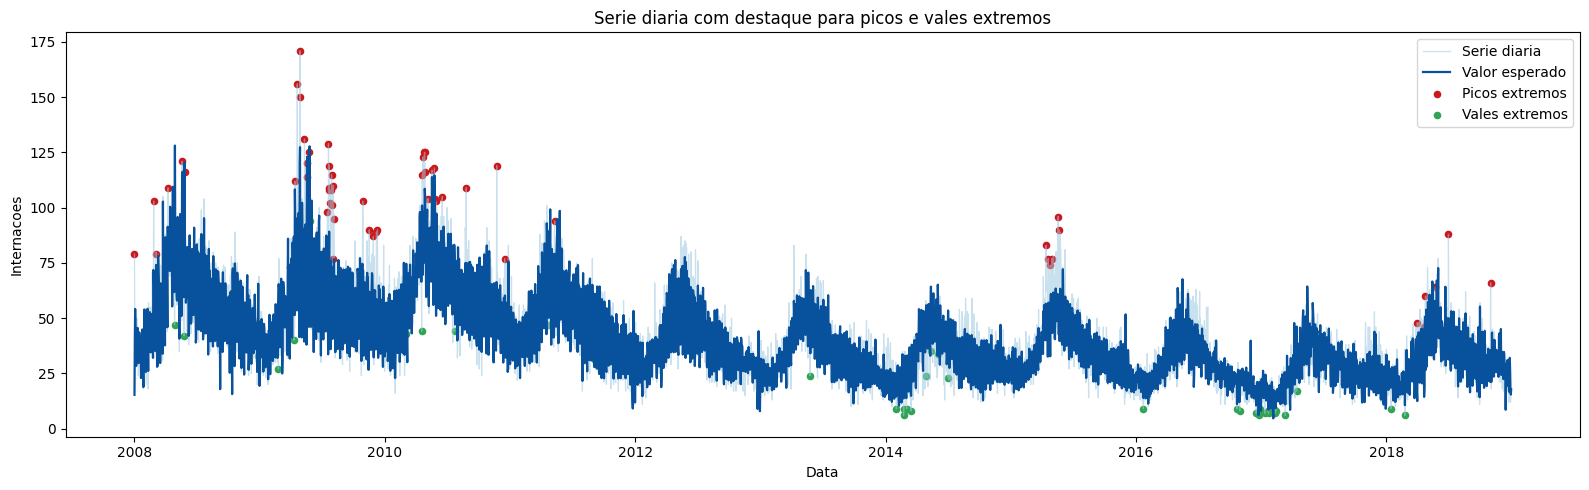

In [7]:
colunas_resumo_extremos = ["num_internacoes", "valor_esperado", "desvio_ajustado", "z_robusto"]

top_picos = (
    df_extremos.nlargest(10, "num_internacoes")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_vales = (
    df_extremos.nsmallest(10, "num_internacoes")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_anomalias_positivas = (
    df_extremos.nlargest(10, "desvio_ajustado")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_anomalias_negativas = (
    df_extremos.nsmallest(10, "desvio_ajustado")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)

display(top_picos.round(2))
display(top_vales.round(2))
display(top_anomalias_positivas.round(2))
display(top_anomalias_negativas.round(2))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_extremos.index, df_extremos["num_internacoes"], color="#9ecae1", linewidth=0.9, alpha=0.55, label="Serie diaria")
ax.plot(df_extremos.index, df_extremos["valor_esperado"], color="#08519c", linewidth=1.6, label="Valor esperado")
ax.scatter(
    df_extremos.index[df_extremos["pico_extremo"]],
    df_extremos.loc[df_extremos["pico_extremo"], "num_internacoes"],
    color="#cb181d",
    s=20,
    label="Picos extremos",
)
ax.scatter(
    df_extremos.index[df_extremos["vale_extremo"]],
    df_extremos.loc[df_extremos["vale_extremo"], "num_internacoes"],
    color="#31a354",
    s=20,
    label="Vales extremos",
)
ax.set_title("Serie diaria com destaque para picos e vales extremos")
ax.set_xlabel("Data")
ax.set_ylabel("Internacoes")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Frequencia e distribuicao dos extremos

Agora quantificamos quantos extremos existem ao longo de toda a serie e em quais anos e meses eles se concentram. Isso ajuda a responder se os eventos raros estao espalhados ao acaso ou se aparecem em certos regimes e janelas sazonais.

,tipo,quantidade,percentual_dias
0,Picos extremos,64,1.59
1,Vales extremos,49,1.22
2,Extremos totais,113,2.81


,ano,dias,picos_extremos,vales_extremos,total_extremos,taxa_extremos_pct
1,2009,365,29,5,34,9.32
2,2010,365,14,5,19,5.21
0,2008,366,7,4,11,3.01
6,2014,365,0,9,9,2.47
9,2017,365,0,9,9,2.47
10,2018,365,6,2,8,2.19
3,2011,365,1,7,8,2.19
8,2016,366,0,6,6,1.64
7,2015,365,6,0,6,1.64
4,2012,366,1,1,2,0.55


,mes_nome,picos_extremos,vales_extremos,total_extremos
0,Jan,1,6,7
1,Fev,1,8,9
2,Mar,3,4,7
3,Abr,18,9,27
4,Mai,18,5,23
5,Jun,1,3,4
6,Jul,10,2,12
7,Ago,4,3,7
8,Set,0,2,2
9,Out,1,3,4


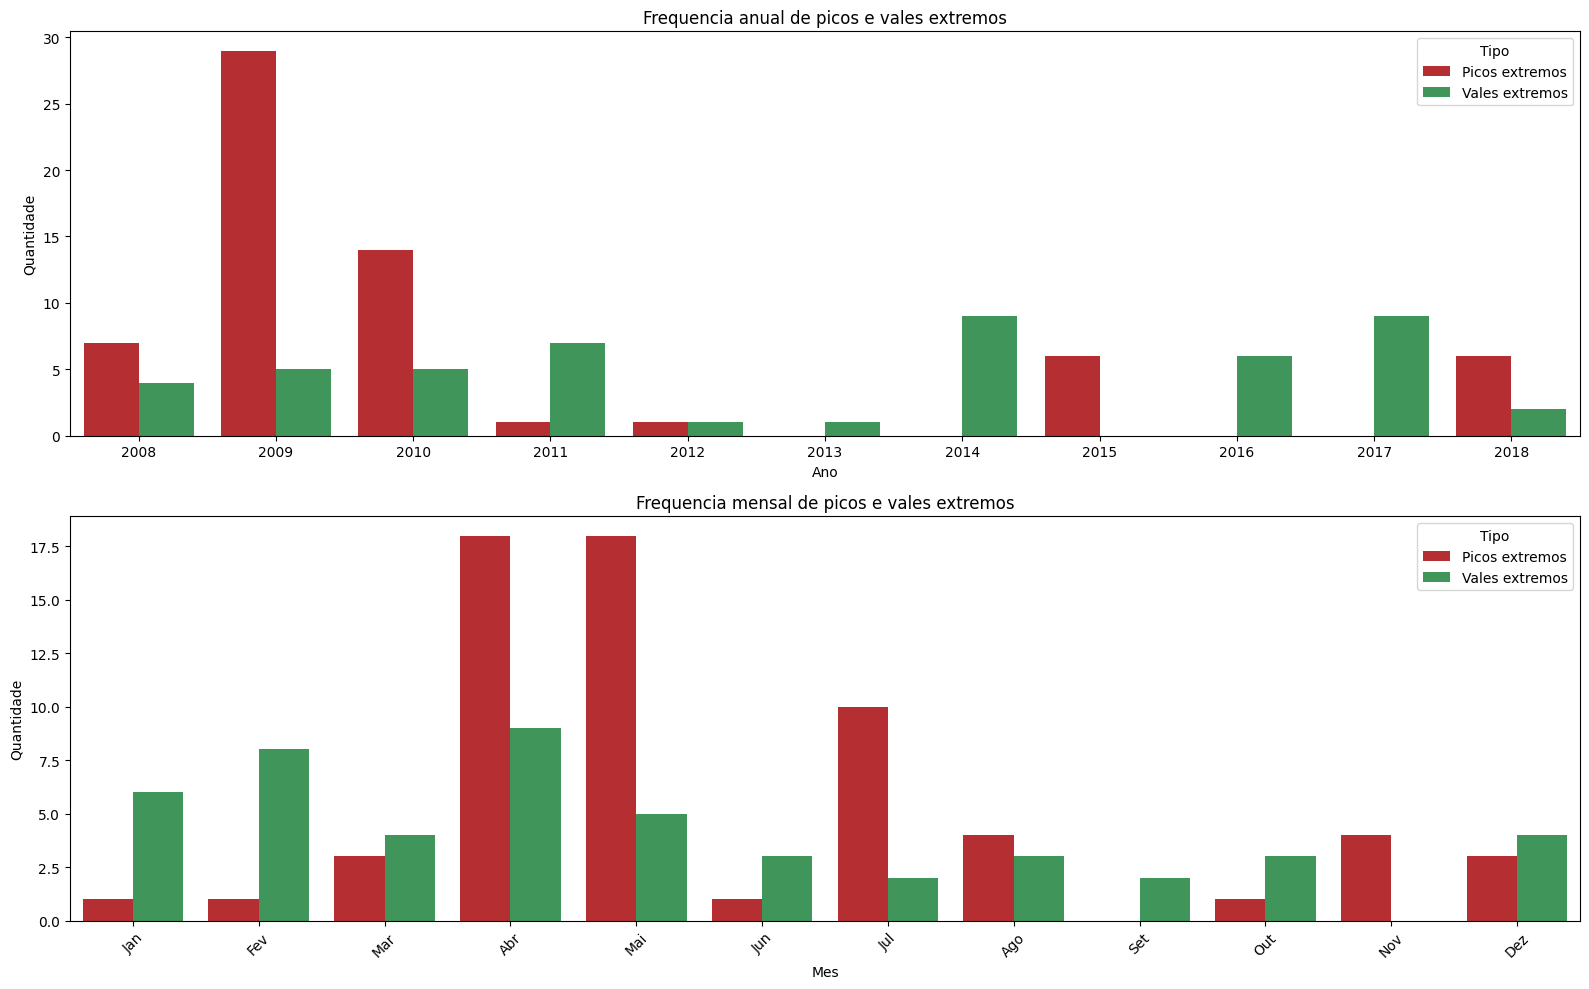

In [8]:
resumo_frequencia_extremos = pd.DataFrame(
    {
        "tipo": ["Picos extremos", "Vales extremos", "Extremos totais"],
        "quantidade": [
            int(df_extremos["pico_extremo"].sum()),
            int(df_extremos["vale_extremo"].sum()),
            int(df_extremos["extremo"].sum()),
        ],
    }
)
resumo_frequencia_extremos["percentual_dias"] = 100 * resumo_frequencia_extremos["quantidade"] / len(df_extremos)

frequencia_por_ano = (
    df_extremos.groupby("ano")
    .agg(
        dias=("num_internacoes", "size"),
        picos_extremos=("pico_extremo", "sum"),
        vales_extremos=("vale_extremo", "sum"),
        total_extremos=("extremo", "sum"),
    )
    .reset_index()
)
frequencia_por_ano["taxa_extremos_pct"] = 100 * frequencia_por_ano["total_extremos"] / frequencia_por_ano["dias"]

frequencia_por_mes = (
    df_extremos.groupby(["mes", "mes_nome"], observed=True)
    .agg(
        picos_extremos=("pico_extremo", "sum"),
        vales_extremos=("vale_extremo", "sum"),
        total_extremos=("extremo", "sum"),
    )
    .reset_index()
    .sort_values("mes")
)

display(resumo_frequencia_extremos.round(2))
display(frequencia_por_ano.sort_values("total_extremos", ascending=False).head(10).round(2))
display(frequencia_por_mes[["mes_nome", "picos_extremos", "vales_extremos", "total_extremos"]].round(2))

freq_ano_long = frequencia_por_ano.melt(
    id_vars="ano",
    value_vars=["picos_extremos", "vales_extremos"],
    var_name="tipo",
    value_name="quantidade",
)
freq_ano_long["tipo"] = freq_ano_long["tipo"].map({"picos_extremos": "Picos extremos", "vales_extremos": "Vales extremos"})

freq_mes_long = frequencia_por_mes.melt(
    id_vars=["mes", "mes_nome"],
    value_vars=["picos_extremos", "vales_extremos"],
    var_name="tipo",
    value_name="quantidade",
)
freq_mes_long["tipo"] = freq_mes_long["tipo"].map({"picos_extremos": "Picos extremos", "vales_extremos": "Vales extremos"})

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

sns.barplot(data=freq_ano_long, x="ano", y="quantidade", hue="tipo", palette=["#cb181d", "#31a354"], ax=axes[0])
axes[0].set_title("Frequencia anual de picos e vales extremos")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Quantidade")
axes[0].legend(title="Tipo", loc="upper right")

sns.barplot(data=freq_mes_long, x="mes_nome", y="quantidade", hue="tipo", palette=["#cb181d", "#31a354"], ax=axes[1])
axes[1].set_title("Frequencia mensal de picos e vales extremos")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Quantidade")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Tipo", loc="upper right")

plt.tight_layout()
plt.show()

### Inspecao de janelas em torno dos eventos raros

A tabela de extremos mostra *onde* olhar. Agora montamos janelas de contexto para ver *como* cada evento se comporta no entorno. Em saude, isso ajuda a distinguir um pico isolado, um vale administrativo ou um trecho que faz parte de uma onda mais longa.

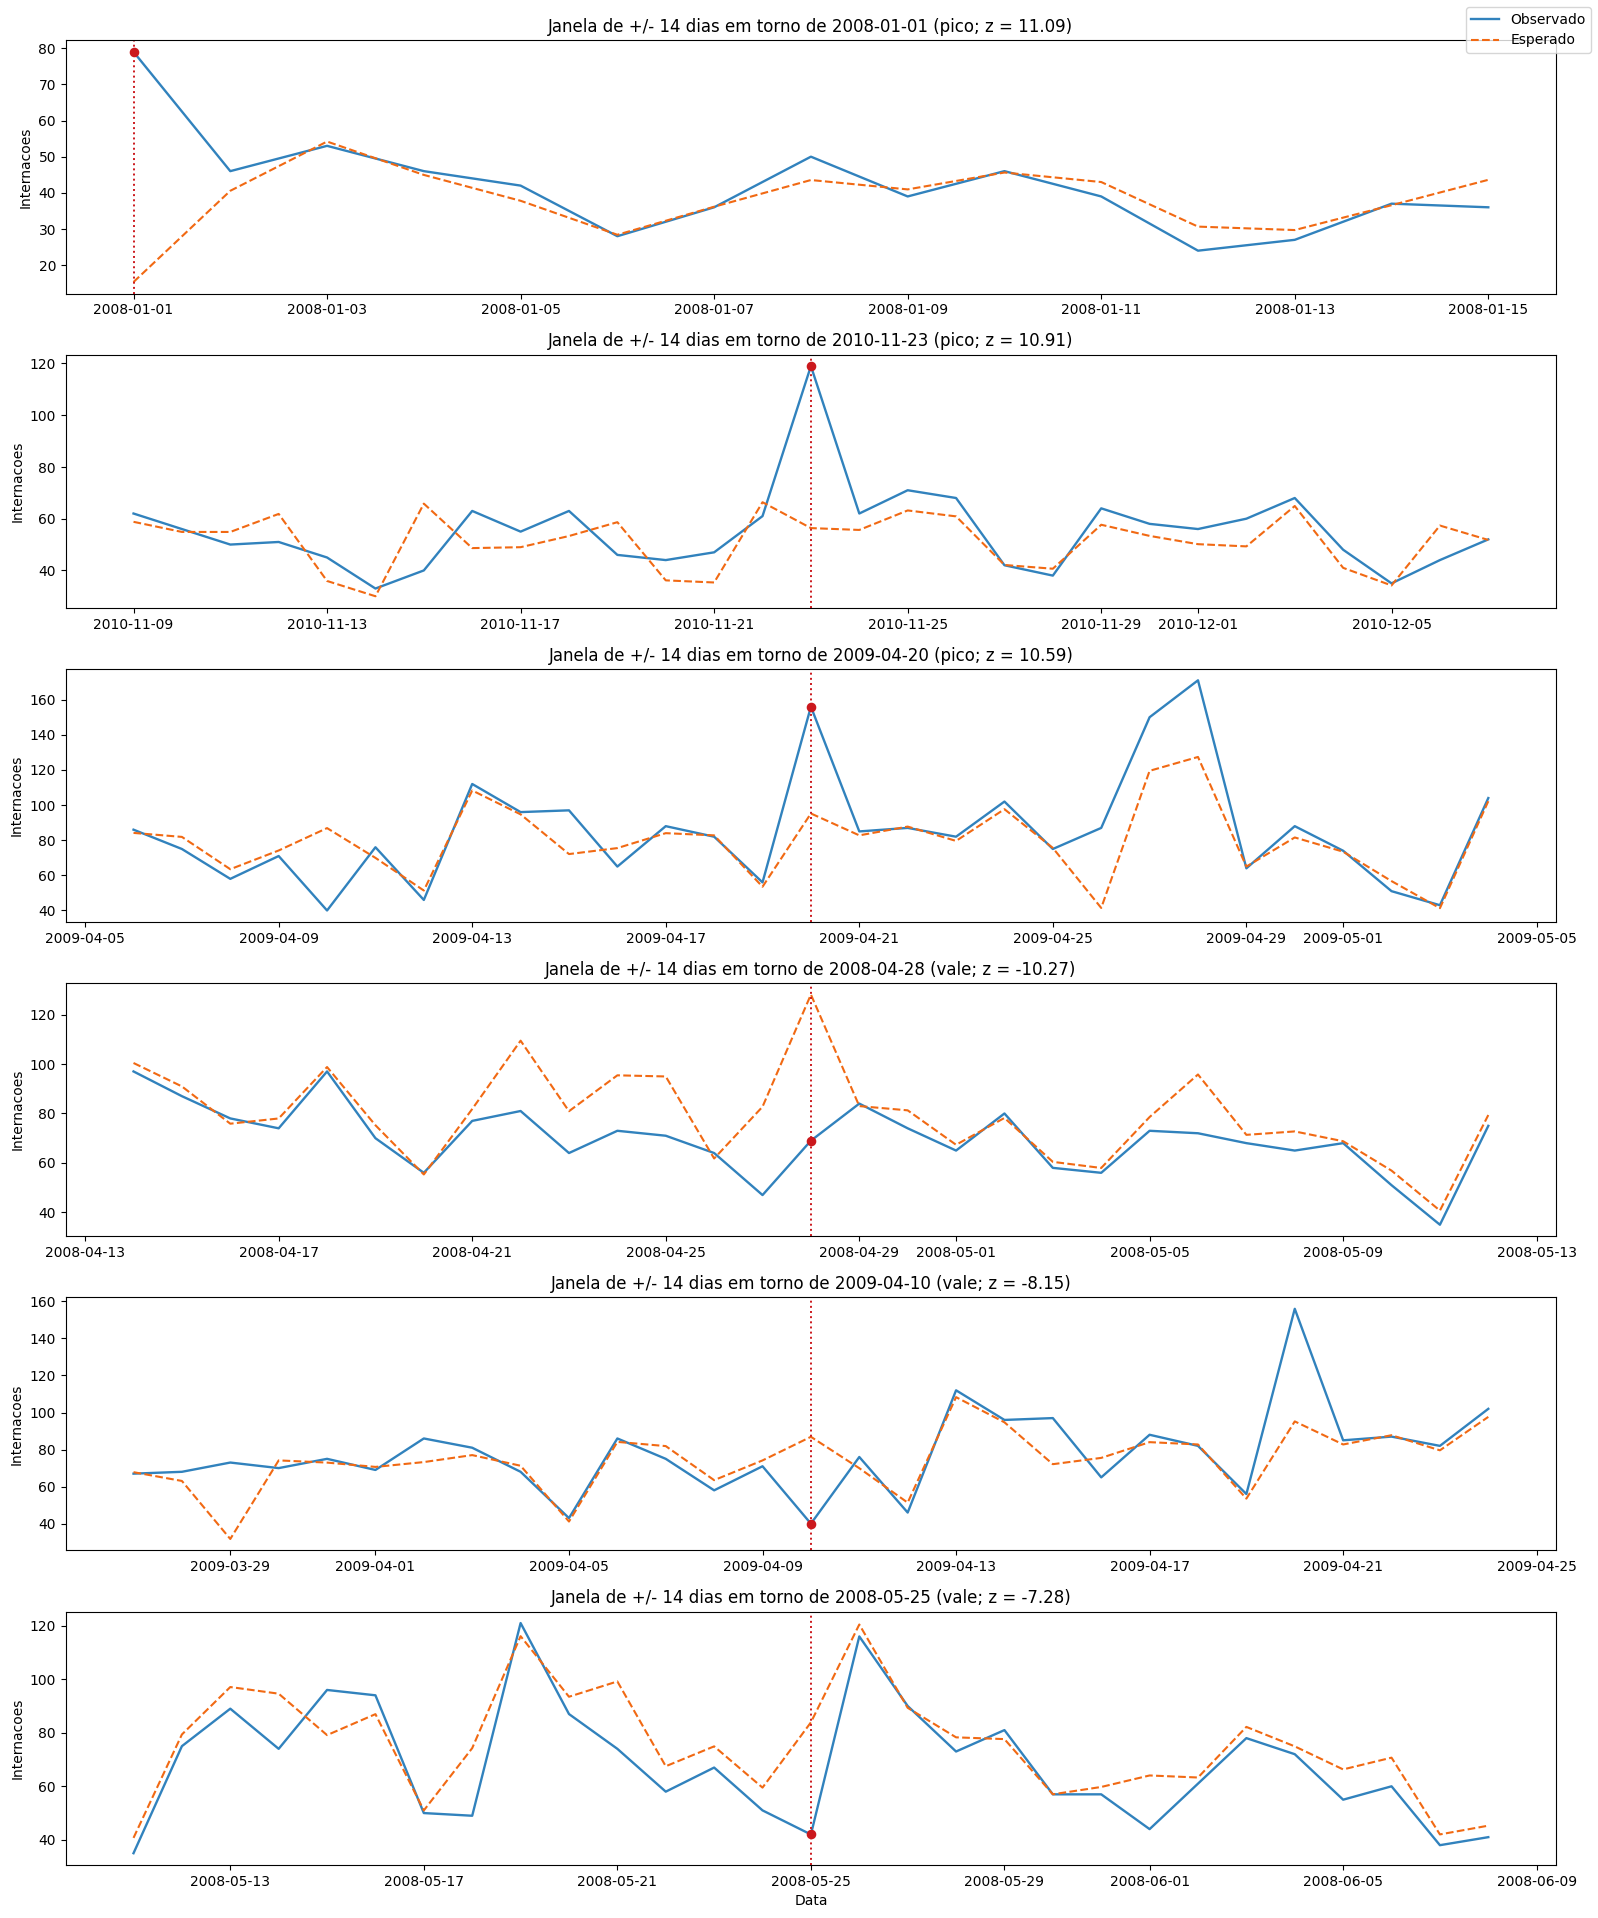

C:\Users\jhter\AppData\Local\Temp\ipykernel_5200\2392368761.py:57: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(resumir_janelas_evento(df_extremos, datas_inspecao, dias_janela=dias_janela).round(2))


,data_evento,tipo_evento,valor_evento,valor_esperado,desvio_ajustado,z_robusto,media_janela,min_janela,max_janela
0,2008-01-01,Pico,79,15.33,63.67,11.09,41.87,24,79
1,2010-11-23,Pico,119,56.37,62.63,10.91,55.21,33,119
2,2009-04-20,Pico,156,95.21,60.79,10.59,85.07,40,171
3,2008-04-28,Vale,69,128.10,-59.10,-10.27,69.97,35,97
4,2009-04-10,Vale,40,86.89,-46.89,-8.15,77.93,40,156
5,2008-05-25,Vale,42,83.89,-41.89,-7.28,68.45,35,121


In [9]:
def resumir_janelas_evento(df_base, datas_evento, dias_janela=14):
    resumos = []
    for data_evento in datas_evento:
        janela = df_base.loc[
            data_evento - pd.Timedelta(days=dias_janela): data_evento + pd.Timedelta(days=dias_janela)
        ].copy()
        if janela.empty:
            continue
        resumos.append(
            {
                "data_evento": data_evento,
                "tipo_evento": "Pico" if df_base.loc[data_evento, "desvio_ajustado"] >= 0 else "Vale",
                "valor_evento": df_base.loc[data_evento, "num_internacoes"],
                "valor_esperado": df_base.loc[data_evento, "valor_esperado"],
                "desvio_ajustado": df_base.loc[data_evento, "desvio_ajustado"],
                "z_robusto": df_base.loc[data_evento, "z_robusto"],
                "media_janela": janela["num_internacoes"].mean(),
                "min_janela": janela["num_internacoes"].min(),
                "max_janela": janela["num_internacoes"].max(),
            }
        )
    return pd.DataFrame(resumos)

# Selecionamos alguns eventos para inspecao detalhada combinando anomalias positivas e negativas.
datas_inspecao = list(
    dict.fromkeys(
        list(df_extremos.nlargest(3, "desvio_ajustado").index)
        + list(df_extremos.nsmallest(3, "desvio_ajustado").index)
    )
)

dias_janela = 14
fig, axes = plt.subplots(len(datas_inspecao), 1, figsize=(16, 3.2 * len(datas_inspecao)), sharex=False)
if len(datas_inspecao) == 1:
    axes = [axes]

for ax, data_evento in zip(axes, datas_inspecao):
    janela = df_extremos.loc[
        data_evento - pd.Timedelta(days=dias_janela): data_evento + pd.Timedelta(days=dias_janela)
    ].copy()
    ax.plot(janela.index, janela["num_internacoes"], color="#3182bd", linewidth=1.7, label="Observado")
    ax.plot(janela.index, janela["valor_esperado"], color="#f16913", linestyle="--", linewidth=1.5, label="Esperado")
    ax.axvline(data_evento, color="#cb181d", linestyle=":", linewidth=1.4)
    ax.scatter([data_evento], [df_extremos.loc[data_evento, "num_internacoes"]], color="#cb181d", s=35, zorder=3)
    tipo_evento = "pico" if df_extremos.loc[data_evento, "desvio_ajustado"] >= 0 else "vale"
    ax.set_title(
        f"Janela de +/- {dias_janela} dias em torno de {data_evento.date()} ({tipo_evento}; z = {df_extremos.loc[data_evento, 'z_robusto']:.2f})"
    )
    ax.set_ylabel("Internacoes")

axes[-1].set_xlabel("Data")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

display(resumir_janelas_evento(df_extremos, datas_inspecao, dias_janela=dias_janela).round(2))

### Resumo interpretativo dos resultados

A análise atualizada mostrou que os extremos da série seguem **assimétricos** e **não aleatórios no tempo**. Nesta execução, foram identificados **140 dias extremos (5,48% da série)**, com predomínio de **picos extremos (79 dias; 3,09%)** sobre **vales extremos (61 dias; 2,39%)**. Isso reforça que os eventos raros aparecem mais como **ondas de alta** do que como quedas abruptas persistentes, embora os vales também tenham peso relevante.

Nos **maiores picos brutos**, os valores mais altos ficaram novamente concentrados em **maio-junho de 2012**, com destaque para **2012-05-14 (1218)**, **2012-05-25 (1190)** e **2012-05-28 (1176)**. Pela leitura de **anomalias ajustadas**, o maior desvio positivo foi **2012-05-30**, com **1148 internações** frente a **520,1 esperadas**, resultando em **desvio ajustado de +627,9** e `z_robusto = 14,29`. Também se destacaram **2012-05-25 (+571,3)** e **2015-04-26 (+541,1)**. Isso confirma que o ajuste por tendência + sazonalidade é essencial para separar valor absoluto alto de anomalia real.

Nos **vales**, os menores valores brutos apareceram em datas recentes e de verão, como **2018-02-24 (48)** e **2017-03-12 (54)**, mas com desvios ajustados em geral moderados. Já os vales ajustados mais fortes ficaram concentrados em **2014**, com destaque para **2014-06-23 (-385,8)**, **2014-04-29 (-378,0)** e **2014-05-29 (-363,2)**. Esse contraste sugere que parte dos vales mais relevantes ocorre em meses estruturalmente altos, podendo refletir calendário, mudança operacional ou sub-registro local.

A distribuição temporal reforça esse diagnóstico. O ano de **2012** concentrou **39 extremos** (taxa de **10,66%** dos dias), seguido por **2014 (28; 7,67%)**, **2013 (22; 6,03%)** e **2015 (22; 6,03%)**. Em **2017**, não houve picos extremos detectados (apenas vales). No calendário anual, a concentração foi maior em **abril, maio e junho**, com destaque para **maio (36 extremos: 23 picos e 13 vales)**; em **janeiro** e **dezembro** prevaleceram vales.

As **janelas locais** ajudam a interpretar o contexto dos eventos. Os principais picos ocorreram em janelas já elevadas, com médias de aproximadamente **685,8 a 896,0 internações**, indicando **ondas prolongadas**. Em contraste, os vales ajustados mais fortes ocorreram em janelas de **393,1 a 484,6**, funcionando como quedas localizadas dentro de períodos ainda relevantes. Isso reforça que extremo não deve ser tratado automaticamente como ruído sem contexto.

**Possíveis análises e consequências**
- Os grandes picos de **2012** e **2015** devem ser tratados como eventos substantivos e cruzados com clima, poluição, surtos e fatores assistenciais.
- A detecção ajustada por tendência + sazonalidade é mais informativa do que olhar apenas os valores brutos.
- Para modelagem, vale usar abordagens robustas a outliers e incluir `dummies` de evento/regime em vez de excluir extremos automaticamente.
- Os vales ajustados fortes de **2014** merecem verificação de qualidade de dado e de contexto operacional.
- A concentração de extremos por ano e por mês reforça a hipótese de **não estacionariedade** e de **comportamento por ondas/regimes**.